# Tasks 23–29: Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/Titanic-Dataset.csv")
df = df.drop_duplicates().copy()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

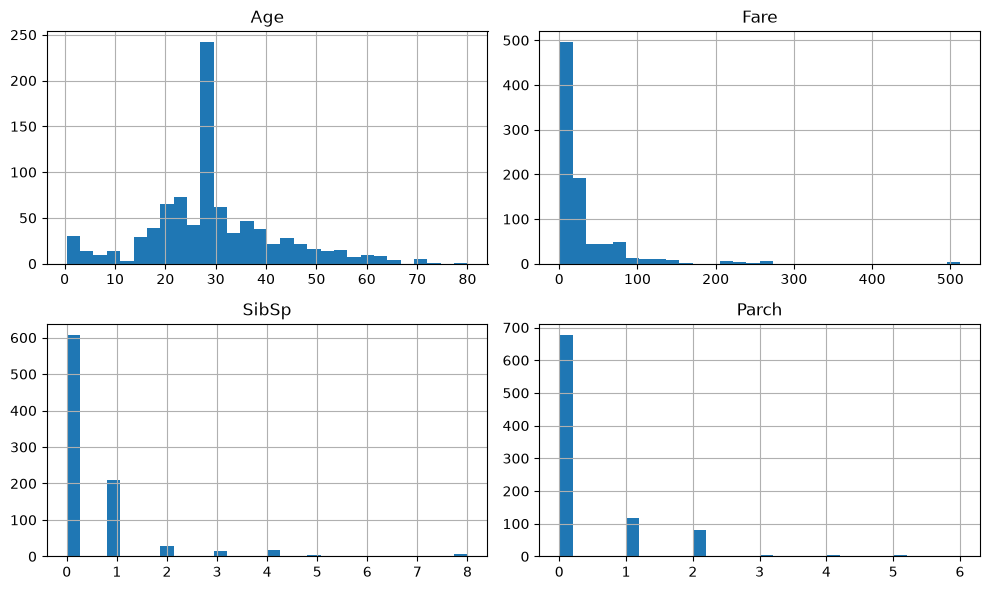

In [2]:
# Task 23: Histograms for numerical features
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
df[numeric_cols].hist(bins=30, figsize=(10, 6), layout=(2, 2))
plt.tight_layout()
plt.show()

**Student Questions (Task 23):**
1. Age distribution: roughly bell-shaped/normal, concentrated between 20-40, with a spike around 28 (median-filled values).
2. Fare distribution: not evenly distributed — heavily right-skewed, most fares are low (under 50) with a long tail of a few very high fares.
3. Most passengers travelled with few or no family members (SibSp and Parch are mostly 0).
4. Fare appears the most strongly skewed numerical variable.

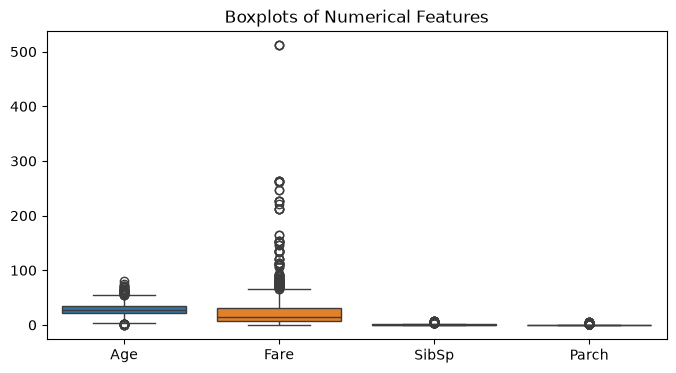

In [3]:
# Task 24: Detect outliers using boxplots
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplots of Numerical Features")
plt.show()

**Student Questions (Task 24):**
1. Fare has the most obvious outliers — several extremely high values well above the rest.
2. Yes, Fare contains unusually high observations (up to 512.33, far above the median of ~14).
3. No — an outlier doesn't automatically mean the value is wrong. These high fares belong to real 1st-class passengers who paid a premium; they're valid extreme values, not errors.

In [4]:
# Task 25: Correlation matrix
selected_cols = ["Age", "SibSp", "Parch", "Pclass", "Fare"]
df[selected_cols].corr()    

,Age,SibSp,Parch,Pclass,Fare
Age,1.000000,-0.233296,-0.172482,-0.339898,0.096688
SibSp,-0.233296,1.000000,0.414838,0.083081,0.159651
Parch,-0.172482,0.414838,1.000000,0.018443,0.216225
Pclass,-0.339898,0.083081,0.018443,1.000000,-0.549500
Fare,0.096688,0.159651,0.216225,-0.549500,1.000000


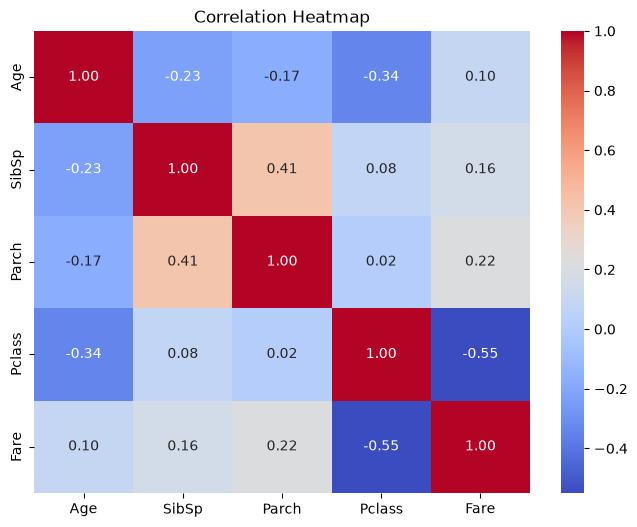

In [5]:
# Task 26: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["Age", "SibSp", "Parch", "Pclass", "Fare"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

**Student Questions (Tasks 25–26):**
1. Strongest positive correlation: SibSp and Parch (0.41)
2. Negative correlations: Pclass & Fare (-0.55, strongest), Pclass & Age (-0.34), Age & SibSp (-0.23)
3. Pclass and Fare show a strong negative relationship — lower Pclass number (1st class) is associated with higher fares, which makes sense since Pclass 1 = most expensive.
4. No — correlation does not prove causation. It only shows two variables move together, not that one causes the other.

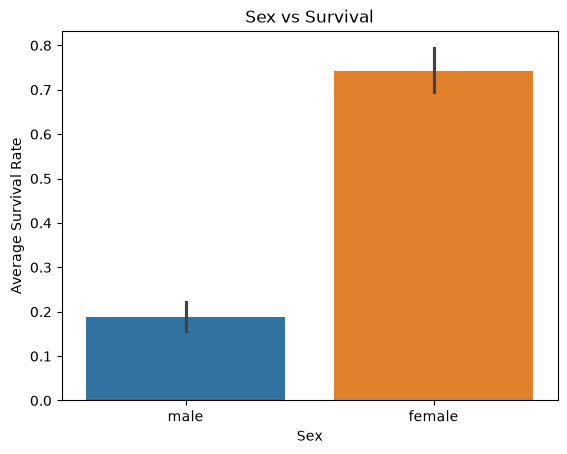

In [6]:
# Task 27: Sex vs Survival bar plot
sns.barplot(x="Sex", y="Survived", data=df, hue="Sex", legend=False)
plt.title("Sex vs Survival")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

In [7]:
# Task 28: Five highest-paying passengers
topFares = df.sort_values(by="Fare", ascending=False)
top5 = topFares.head(5)
top5[["Name", "Sex", "Pclass", "Fare"]]

,Name,Sex,Pclass,Fare
679,"Cardeza, Mr. Thomas Drake Martinez",male,1,512.3292
258,"Ward, Miss. Anna",female,1,512.3292
737,"Lesurer, Mr. Gustave J",male,1,512.3292
88,"Fortune, Miss. Mabel Helen",female,1,263.0000
438,"Fortune, Mr. Mark",male,1,263.0000


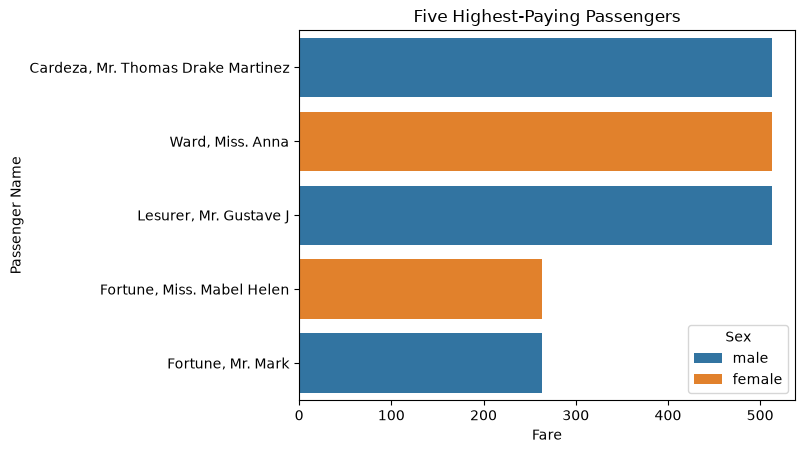

In [8]:
# Task 29: Visualize five highest-paying passengers
sns.barplot(x="Fare", y="Name", data=top5, hue="Sex")
plt.title("Five Highest-Paying Passengers")
plt.xlabel("Fare")
plt.ylabel("Passenger Name")
plt.show()

**Student Questions (Tasks 28–29):**
1. Highest fare paid: 512.33, by three passengers (Cardeza, Mr. Thomas Drake Martinez; Ward, Miss. Anna; Lesurer, Mr. Gustave J) — a tie.
2. All five highest-paying passengers were in 1st class.
3. Their fares are far above the typical fare (mean ≈32, median ≈14) — these are clear outliers as seen in the boxplot.

## Final Conclusion

The Titanic dataset contains 891 passenger records across 12 columns, combining numerical (Age, Fare, SibSp, Parch, Pclass) and categorical (Sex, Embarked, Cabin) features. Three columns had missing data: Age (19.87%), Embarked (0.22%), and Cabin (77.10%) — Age was filled using the median and Embarked using the mode, while Cabin was left unchanged due to excessive missingness. No duplicate rows were found. The overall survival rate was 38.38%, with a striking gap between sexes (female 74.20% vs male 18.89%) and a clear class effect (1st class 62.96% down to 3rd class 24.24%), suggesting both sex and socioeconomic status strongly influenced survival chances. Fare was the most skewed numerical variable, with a small number of very high-paying 1st-class passengers appearing as clear outliers, and Pclass and Fare showed the strongest correlation (-0.55) among numerical features. Overall, this EDA highlights that survival on the Titanic was not random — it was closely tied to who you were (sex) and what you could afford (class) — and demonstrates how cleaning, grouping, and visualizing data are essential steps before any further statistical or machine-learning analysis.